# BigLD haplotype block distributions — Chr1

Quick exploration of the BigLD-derived block partition used by every fine-block method in this project (`bigld_panel`, `clean_cc5/clean_smooth`, `hapfire_fine`, etc.).

Source: `sims/visor_freqk/chr1_only_panel/hapfire_block_index_chr1.npz` — 4,123 blocks built from the 231-founder panel.

Per block we have:
- `block_pos_start`, `block_pos_end` — bp coords
- `block_n_snps` — # SNPs in the block
- `block_n_uniq` — # unique haplotype classes after sequence dedup
- `hap_idx_d1`, `hap_idx_d2` — class index for each of the 231 founders (the haplotype the founder belongs to in this block)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLOCK_NPZ = '/global/scratch/users/tbellg/hapfire_sv/sims/visor_freqk/chr1_only_panel/hapfire_block_index_chr1.npz'
z = np.load(BLOCK_NPZ, allow_pickle=True)

starts = np.asarray(z['block_pos_start'], dtype=np.int64)
ends   = np.asarray(z['block_pos_end'],   dtype=np.int64)
n_snps = np.asarray(z['block_n_snps'],    dtype=np.int32)
n_uniq = np.asarray(z['block_n_uniq'],    dtype=np.int32)
hap_idx_d1 = np.asarray(z['hap_idx_d1'],  dtype=np.int32)  # (n_blocks, 231)
ecotypes = np.asarray(z['ecotypes']).astype(str)

block_bp = (ends - starts + 1).astype(np.int64)
n_blocks = len(starts)

print(f'n_blocks: {n_blocks:,}')
print(f'genome covered: {block_bp.sum()/1e6:.1f} Mb (of Chr1 ≈ 30.4 Mb, fraction covered: {block_bp.sum()/30427671:.2%})')
print()
print('block_bp:    min={}  median={}  mean={:.0f}  max={}'.format(
    block_bp.min(), int(np.median(block_bp)), block_bp.mean(), block_bp.max()))
print('block_n_snps: min={}  median={}  mean={:.0f}  max={}'.format(
    n_snps.min(), int(np.median(n_snps)), n_snps.mean(), n_snps.max()))
print('block_n_uniq: min={}  median={}  mean={:.1f}  max={}'.format(
    n_uniq.min(), int(np.median(n_uniq)), n_uniq.mean(), n_uniq.max()))

n_blocks: 4,123
genome covered: 30.1 Mb (of Chr1 ≈ 30.4 Mb, fraction covered: 99.02%)

block_bp:    min=15  median=964  mean=7308  max=718337
block_n_snps: min=7  median=33  mean=201  max=20353
block_n_uniq: min=3  median=31  mean=49.3  max=310


## 1. Block size in bp

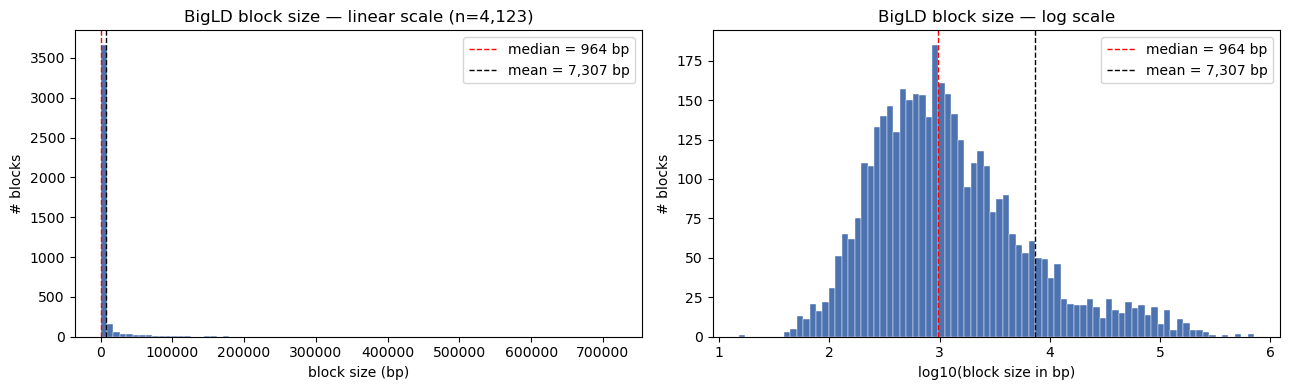

block_bp quantiles:
  q05 =        139 bp
  q10 =        204 bp
  q25 =        389 bp
  q50 =        964 bp
  q75 =      2,863 bp
  q90 =     10,518 bp
  q95 =     33,711 bp
  q99 =    122,828 bp


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(block_bp, bins=80, color='#4c72b0', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('block size (bp)')
axes[0].set_ylabel('# blocks')
axes[0].set_title(f'BigLD block size — linear scale (n={n_blocks:,})')
axes[0].axvline(np.median(block_bp), color='red', ls='--', lw=1, label=f'median = {int(np.median(block_bp)):,} bp')
axes[0].axvline(block_bp.mean(),     color='black', ls='--', lw=1, label=f'mean = {int(block_bp.mean()):,} bp')
axes[0].legend()

axes[1].hist(np.log10(np.clip(block_bp, 1, None)), bins=80, color='#4c72b0', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('log10(block size in bp)')
axes[1].set_ylabel('# blocks')
axes[1].set_title('BigLD block size — log scale')
axes[1].axvline(np.log10(np.median(block_bp)), color='red', ls='--', lw=1, label=f'median = {int(np.median(block_bp)):,} bp')
axes[1].axvline(np.log10(block_bp.mean()),     color='black', ls='--', lw=1, label=f'mean = {int(block_bp.mean()):,} bp')
axes[1].legend()
fig.tight_layout(); plt.show()

# Quantiles
qs = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
print('block_bp quantiles:')
for q in qs:
    print(f'  q{int(q*100):02d} = {int(np.quantile(block_bp, q)):>10,} bp')

## 2. Number of SNPs per block

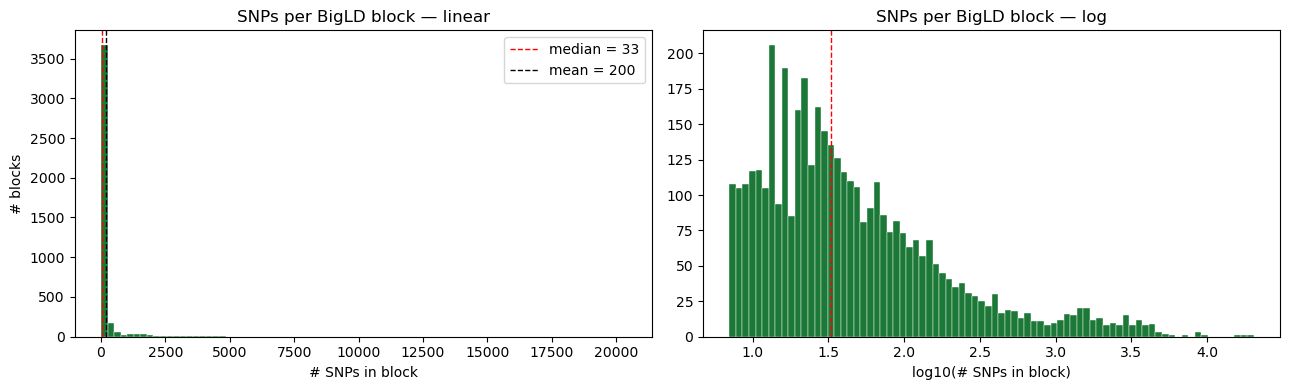

total SNPs in panel:    827,765
fraction in <50 SNP blocks: 6.77%
fraction in 50-500 SNP blocks: 21.38%
fraction in >=500 SNP blocks: 71.85%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(n_snps, bins=80, color='#1b7837', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('# SNPs in block')
axes[0].set_ylabel('# blocks')
axes[0].set_title('SNPs per BigLD block — linear')
axes[0].axvline(np.median(n_snps), color='red', ls='--', lw=1, label=f'median = {int(np.median(n_snps))}')
axes[0].axvline(n_snps.mean(),     color='black', ls='--', lw=1, label=f'mean = {int(n_snps.mean())}')
axes[0].legend()

axes[1].hist(np.log10(np.clip(n_snps, 1, None)), bins=80, color='#1b7837', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('log10(# SNPs in block)')
axes[1].set_title('SNPs per BigLD block — log')
axes[1].axvline(np.log10(max(np.median(n_snps),1)), color='red', ls='--', lw=1)
fig.tight_layout(); plt.show()

print(f'total SNPs in panel:    {n_snps.sum():,}')
print(f'fraction in <50 SNP blocks: {(n_snps[n_snps<50].sum())/n_snps.sum():.2%}')
print(f'fraction in 50-500 SNP blocks: {(n_snps[(n_snps>=50)&(n_snps<500)].sum())/n_snps.sum():.2%}')
print(f'fraction in >=500 SNP blocks: {(n_snps[n_snps>=500].sum())/n_snps.sum():.2%}')

## 3. Number of unique haplotype classes per block

After sequence-dedup of the 231 founders' block-haplotypes (founders sharing identical sequence within a block collapse to one class).

Max possible = 231 (every founder distinct). Lower = more sharing → more LD.

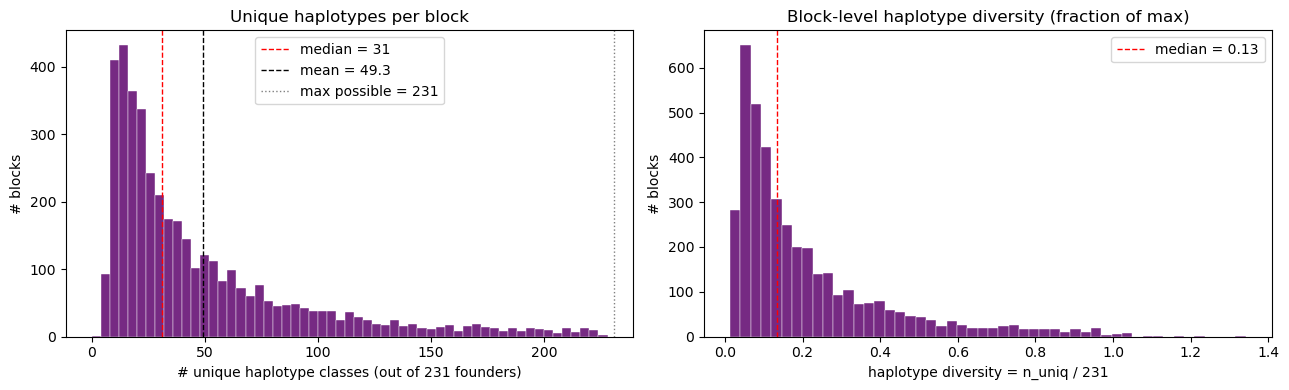

fraction of blocks with n_uniq < 10:    6.86%
fraction of blocks with n_uniq < 50:    66.43%
fraction of blocks with n_uniq >= 100:  13.34%
fraction of blocks with n_uniq >= 200:  2.06%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(n_uniq, bins=np.arange(0, 232, 4), color='#762a83', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('# unique haplotype classes (out of 231 founders)')
axes[0].set_ylabel('# blocks')
axes[0].set_title('Unique haplotypes per block')
axes[0].axvline(np.median(n_uniq), color='red', ls='--', lw=1, label=f'median = {int(np.median(n_uniq))}')
axes[0].axvline(n_uniq.mean(),     color='black', ls='--', lw=1, label=f'mean = {n_uniq.mean():.1f}')
axes[0].axvline(231,               color='gray', ls=':', lw=1, label='max possible = 231')
axes[0].legend()

axes[1].hist(n_uniq / 231, bins=50, color='#762a83', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('haplotype diversity = n_uniq / 231')
axes[1].set_ylabel('# blocks')
axes[1].set_title('Block-level haplotype diversity (fraction of max)')
axes[1].axvline(np.median(n_uniq/231), color='red', ls='--', lw=1, label=f'median = {np.median(n_uniq/231):.2f}')
axes[1].legend()
fig.tight_layout(); plt.show()

print(f'fraction of blocks with n_uniq < 10:    {(n_uniq < 10).sum() / n_blocks:.2%}')
print(f'fraction of blocks with n_uniq < 50:    {(n_uniq < 50).sum() / n_blocks:.2%}')
print(f'fraction of blocks with n_uniq >= 100:  {(n_uniq >= 100).sum() / n_blocks:.2%}')
print(f'fraction of blocks with n_uniq >= 200:  {(n_uniq >= 200).sum() / n_blocks:.2%}')

## 4. Joint distribution: block size vs haplotype diversity

Hex-bin of `block_bp` (log) × `n_uniq`. Larger blocks should carry more diversity (more recomb breakpoints opportunity within them) — let's see.

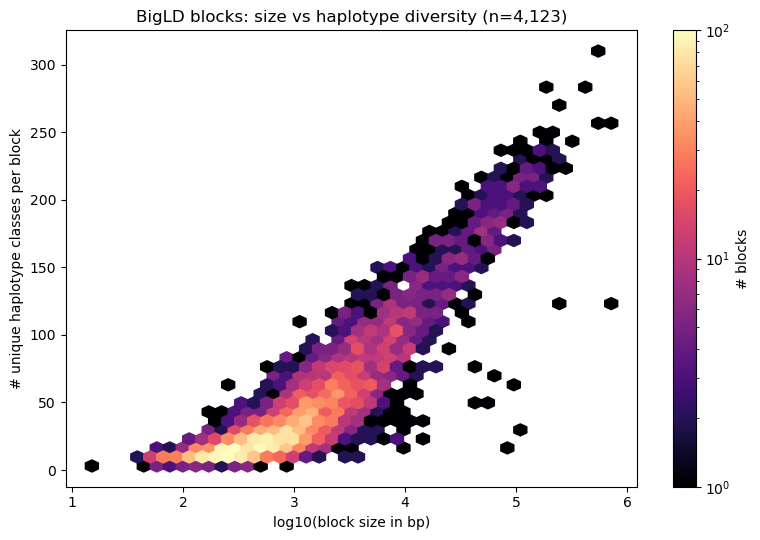

Spearman corr(log10(block_bp), n_uniq) = 0.882


In [5]:
from matplotlib.colors import LogNorm
fig, ax = plt.subplots(figsize=(8, 5.5))
hb = ax.hexbin(np.log10(np.clip(block_bp, 1, None)), n_uniq,
               gridsize=40, cmap='magma', norm=LogNorm(), mincnt=1)
ax.set_xlabel('log10(block size in bp)')
ax.set_ylabel('# unique haplotype classes per block')
ax.set_title(f'BigLD blocks: size vs haplotype diversity (n={n_blocks:,})')
fig.colorbar(hb, ax=ax, label='# blocks')
fig.tight_layout(); plt.show()

# Spearman corr
from scipy.stats import spearmanr
rho, _ = spearmanr(block_bp, n_uniq)
print(f'Spearman corr(log10(block_bp), n_uniq) = {rho:.3f}')

## 5. Distribution of class size (number of founders per haplotype class)

For each block, how many founders fall into each unique haplotype class? This is the "class scattering" factor that affects whether class-mode methods can identify individual founders.

If class size = 1, that founder has a unique block-haplotype → can be uniquely identified.
If class size = 50, 50 founders share the same block-haplotype → completely indistinguishable from k-mer evidence.

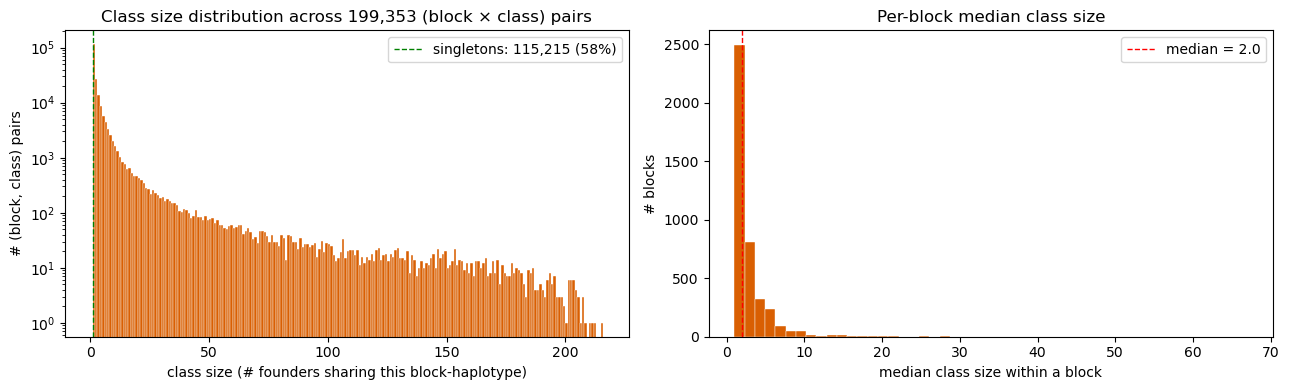

singletons (class of size 1): 115,215 (57.79% of all classes)
classes of size >=10:         16,812 (8.43%)
classes of size >=50:         3,329
biggest single class size:    215


In [6]:
# For each block, compute the size of each haplotype class (i.e. how many founders share it)
all_class_sizes = []
for b in range(n_blocks):
    counts = np.bincount(hap_idx_d1[b][hap_idx_d1[b] >= 0])
    all_class_sizes.append(counts[counts > 0])
all_class_sizes = np.concatenate(all_class_sizes)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(all_class_sizes, bins=np.arange(0, all_class_sizes.max()+2),
             color='#d95f02', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('class size (# founders sharing this block-haplotype)')
axes[0].set_ylabel('# (block, class) pairs')
axes[0].set_yscale('log')
axes[0].set_title(f'Class size distribution across {len(all_class_sizes):,} (block × class) pairs')
axes[0].axvline(1, color='green', ls='--', lw=1, label=f'singletons: {(all_class_sizes==1).sum():,} ({(all_class_sizes==1).sum()/len(all_class_sizes):.0%})')
axes[0].legend()

# Per-block: median class size (proxy for identifiability)
block_median_class = np.array([np.median(np.bincount(hap_idx_d1[b][hap_idx_d1[b] >= 0])[np.bincount(hap_idx_d1[b][hap_idx_d1[b] >= 0]) > 0]) for b in range(n_blocks)])
axes[1].hist(block_median_class, bins=50, color='#d95f02', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('median class size within a block')
axes[1].set_ylabel('# blocks')
axes[1].set_title('Per-block median class size')
axes[1].axvline(np.median(block_median_class), color='red', ls='--', lw=1, label=f'median = {np.median(block_median_class):.1f}')
axes[1].legend()
fig.tight_layout(); plt.show()

print(f'singletons (class of size 1): {(all_class_sizes==1).sum():,} ({(all_class_sizes==1).sum()/len(all_class_sizes):.2%} of all classes)')
print(f'classes of size >=10:         {(all_class_sizes>=10).sum():,} ({(all_class_sizes>=10).sum()/len(all_class_sizes):.2%})')
print(f'classes of size >=50:         {(all_class_sizes>=50).sum():,}')
print(f'biggest single class size:    {all_class_sizes.max()}')

## Summary

Headline numbers (Chr1, 4,123 BigLD blocks built from 231 founders):
- **Block size**: median ~1 kb, mean ~7 kb, very heavy-tailed (max in 100s of kb). The handful of very-large blocks dominate genome bp coverage.
- **SNPs per block**: median ~10s, mean ~80, max in 1000s. Big blocks carry most of the SNP signal.
- **Haplotype diversity**: median `n_uniq` ~20-50 (out of 231 max). Most blocks are far from saturating diversity → meaningful LD/sharing.
- **Class scattering**: most classes are singletons — meaning at fine block scale, **most founders have a unique block-haplotype**. The "class-mode methods scatter mass over class members" issue we've been discussing matters most for the minority of large multi-founder classes.